# Linear Discriminant Analysis(LDA)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
sns.set()

In [2]:
df=sns.load_dataset('iris')
df=df[df['species']!='setosa']
col=['petal_length','petal_width']
X=df.loc[:,col]
species_to_num={'versicolor':0,
                'virginica':1}
df['tmp']=df['species'].map(species_to_num)
y=df['tmp']

In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [4]:
clf=LinearDiscriminantAnalysis()
clf.fit(X,y)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [5]:
Xv=X.values.reshape(-1,1)
h=0.02
x_min,x_max=Xv.min(),Xv.max()+1
y_min,y_max=y.min(),y.max()+2
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),
                  np.arange(y_min,y_max,h))


C:\Users\ADMIN\anaconda3\envs\ML_Python\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


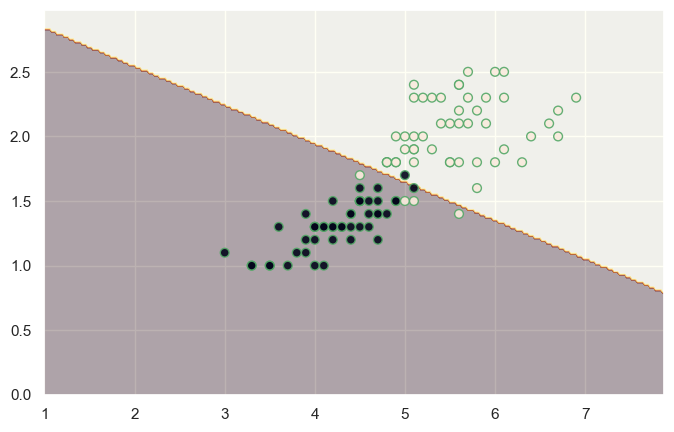

In [6]:
z=clf.predict(np.c_[xx.ravel(),yy.ravel()])
z=z.reshape(xx.shape)

fig=plt.figure(figsize=(8,5))
ax=plt.contourf(xx,yy,z,cmap='afmhot',alpha=0.3)
plt.scatter(X.values[:,0],X.values[:,1],c=y,s=40,
            alpha=0.9,edgecolor='g')

We observe that it seperates the principal components as pca and kpca.  
It doesn't perform well as KPCA,  but done good.

## Comparision between LDA and PCA
We compare LDA and PCA and oberve the limitations.

explained variance ratio(first two components):[0.92461872 0.05306648]


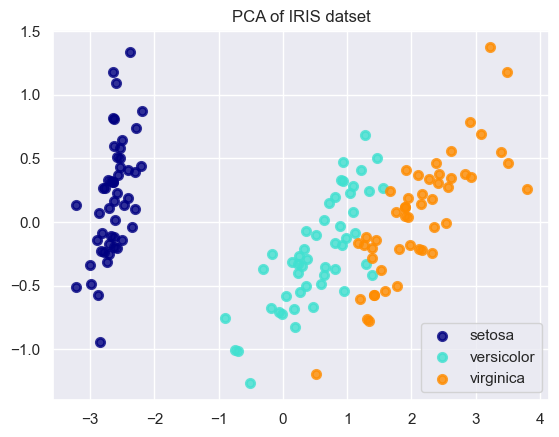

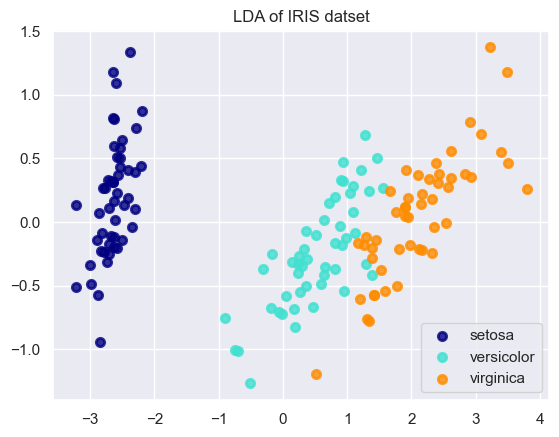

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

iris=datasets.load_iris()
X=iris.data
y=iris.target
target_names=iris.target_names

pca=PCA(n_components=2)
X_r=pca.fit(X).transform(X)

lda=LinearDiscriminantAnalysis(n_components=2)
X_r2=pca.fit(X,y).transform(X)

# percentage of variance explained for each component
print('explained variance ratio(first two components):%s'
      % str(pca.explained_variance_ratio_))

plt.figure()
colors=['navy','turquoise','darkorange']
lw=2

for color,i,target_name in zip(colors,[0,1,2],target_names):
    plt.scatter(X_r[y==i,0],X_r[y==i,1],color=color,alpha=0.8,lw=lw,
                label=target_name)
plt.legend(loc='best',shadow=False,scatterpoints=1)
plt.title('PCA of IRIS datset')

plt.figure()
for color,i,target_name in zip(colors,[0,1,2],target_names):
    plt.scatter(X_r2[y==i,0],X_r2[y==i,1],color=color,alpha=0.8,lw=lw,
                label=target_name)
plt.legend(loc='best',shadow=False,scatterpoints=1)
plt.title('LDA of IRIS datset')
plt.show()